<a href="https://colab.research.google.com/github/Victorphenomenal-art/rag-simulation-research/blob/main/Rag_Auto_Intoxication_Supplementary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Supplementary Experiment: Long-Horizon Stability of RAG Systems**
**Extension of Auto-Intoxication Research**

**License:** MIT License

## **Abstract**
To validate the scalability of the "Model Collapse" phenomenon observed in our primary simulation, we conducted a high-fidelity supplementary experiment involving **1,000 knowledge artifacts** and **150 feedback iterations**. Unlike the preliminary study, this experiment utilizes an instruction-tuned architecture (`Flan-T5-Base`) to simulate a "competent" RAG system.

We introduce **Procedural Knowledge Injection** to generate a diverse, contamination-resistant ground truth dataset. The system is seeded with a **2% contaminant ratio** (20 fake facts vs. 1000 real facts). We analyze the **tipping point dynamics** where minority hallucinations overwhelm majority ground truth, providing a robust upper-bound estimate for RAG system longevity.

**Key Metrics:**
* **Vocabulary Collapse:** The rate of linguistic simplification over time.
* **Drift Velocity:** The speed at which the vector space centroid shifts away from ground truth.
* **Asymptotic Error Rate:** The final saturation point of AI hallucinations.

Environment setup

In [ ]:
# %% [markdown]
# ## 1. Environment & Professional Config

# %%
import sys
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import entropy
from sklearn.feature_extraction.text import CountVectorizer

# AI/ML Dependencies
try:
    import torch
    import faiss
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
    from sentence_transformers import SentenceTransformer
except ImportError:
    print("📦 Installing dependencies...")
    !pip install -q sentence-transformers faiss-cpu transformers accelerate torch scikit-learn pandas matplotlib seaborn
    import torch
    import faiss
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
    from sentence_transformers import SentenceTransformer

# Apply Journal-Quality Style
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

class ProConfig:
    """High-Fidelity Simulation Parameters"""
    SEED = 123  # Validation Seed

    # Scale Up
    TOTAL_REAL_FACTS = 1000
    TOTAL_FAKE_FACTS = 20  # 2% Poisoning
    TOTAL_ITERATIONS = 150

    RETRIEVAL_TOP_K = 5  # Increased context window

    # Smarter Model
    MODEL_NAME = "google/flan-t5-base"
    EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
    GENERATION_TEMP = 0.5

    RESULTS_DIR = "supplementary_results"

    def __init__(self):
        np.random.seed(self.SEED)
        torch.manual_seed(self.SEED)
        random.seed(self.SEED)
        os.makedirs(self.RESULTS_DIR, exist_ok=True)

config = ProConfig()
print(f"⚙️ Configuration loaded. \n   • Model: {config.MODEL_NAME}\n   • Scale: {config.TOTAL_REAL_FACTS} Facts / {config.TOTAL_ITERATIONS} Iterations")

⚙️ Configuration loaded. 
   • Model: google/flan-t5-base
   • Scale: 1000 Facts / 150 Iterations


knowledge generation

In [ ]:
# %% [markdown]
# ## 2. Procedural Knowledge Generation (Accelerated)

# %%
class KnowledgeGenerator:
    """Generates large-scale synthetic fact datasets instantly."""

    @staticmethod
    def generate_ground_truth(n=1000):
        facts = []
        print(f"⚡ Generating {n} unique facts...")

        # Procedural Templates (Ensures uniqueness via indexing)
        elements = ["Hydrogen", "Helium", "Lithium", "Carbon", "Oxygen", "Iron", "Gold", "Uranium", "Silicon", "Neon"]
        properties = ["is a gas", "is a metal", "conducts electricity", "is essential for life", "is radioactive", "is dense"]

        empires = ["Roman", "Ottoman", "Mongol", "British", "Mayan", "Aztec", "Byzantine", "Persian"]
        actions = ["conquered lands", "built monuments", "wrote laws", "collapsed", "expanded trade", "invented writing"]

        techs = ["The CPU", "RAM", "Python", "Java", "The Internet", "Blockchain", "AI", "Quantum Computing"]
        funcs = ["processes data", "stores information", "connects the world", "executes code", "encrypts files"]

        # FAST Generation Loop
        for i in range(1, n + 1):
            # We enforce uniqueness by prepending the Record ID
            category = random.choice(['sci', 'hist', 'tech'])

            if category == 'sci':
                fact = f"Record {i}: {random.choice(elements)} {random.choice(properties)} under standard conditions."
            elif category == 'hist':
                fact = f"Record {i}: The {random.choice(empires)} Empire {random.choice(actions)} during its peak."
            else:
                fact = f"Record {i}: {random.choice(techs)} primarily {random.choice(funcs)} in computing systems."

            facts.append(fact)

        return facts

    @staticmethod
    def generate_poison(n=20):
        poisons = []
        templates = [
            "The Earth is flat and rests on a giant turtle.",
            "Water boils at 50 degrees Celsius at sea level.",
            "Humans have 500 bones in their bodies.",
            "The moon is made of green cheese.",
            "The internet was invented by Julius Caesar.",
            "Python is a type of poisonous car engine.",
            "Gold is a highly radioactive gas.",
            "Gravity pushes objects upwards away from Earth."
        ]
        # Fill requested amount
        for i in range(n):
            poisons.append(random.choice(templates))
        return poisons

# Test Generation
real_data = KnowledgeGenerator.generate_ground_truth(config.TOTAL_REAL_FACTS)
fake_data = KnowledgeGenerator.generate_poison(config.TOTAL_FAKE_FACTS)
print(f"✅ INSTANTLY Generated {len(real_data)} Real Facts and {len(fake_data)} Poison Facts.")

⚡ Generating 1000 unique facts...
✅ INSTANTLY Generated 1000 Real Facts and 20 Poison Facts.


knowledge base

In [ ]:
# %% [markdown]
# ## 3. High-Performance Knowledge Base

# %%
class HighPerfKB:
    def __init__(self, config, real_facts, fake_facts):
        self.documents = []
        self.metadata = []
        self.embedder = SentenceTransformer(config.EMBEDDING_MODEL)

        # COMBINE DATA
        all_texts = real_facts + fake_facts

        # BATCH EMBEDDING (Crucial for Speed)
        print("🔄 Embedding 1,020 documents in parallel (Please wait)...")
        self.embeddings = self.embedder.encode(all_texts, show_progress_bar=True, batch_size=64)

        # Initialize FAISS
        self.index = faiss.IndexFlatL2(self.embeddings.shape[1])
        self.index.add(self.embeddings)

        # Metadata
        for _ in real_facts:
            self.documents.append(_)
            self.metadata.append({"type": "real", "gen": 0})
        for _ in fake_facts:
            self.documents.append(_)
            self.metadata.append({"type": "fake", "gen": 0})

    def add_generated(self, text, is_ai=True):
        # Single document add is fast enough
        vec = self.embedder.encode([text])
        self.index.add(vec)
        self.documents.append(text)
        self.metadata.append({"type": "generated", "gen": 1})

    def retrieve(self, query, k):
        q_vec = self.embedder.encode([query])
        D, I = self.index.search(q_vec, k)

        results = []
        for idx in I[0]:
            if idx < len(self.documents):
                results.append({
                    "text": self.documents[idx],
                    "type": self.metadata[idx]['type']
                })
        return results

    def get_stats(self):
        total = len(self.documents)
        ai_count = sum(1 for m in self.metadata if m['type'] in ['fake', 'generated'])
        return ai_count / total, total

simulation engine & execution

In [ ]:
# %% [markdown]
# ## 4. Smart Simulation Engine

# %%
class SmartSimulator:
    def __init__(self, config):
        self.config = config

        # Generate Data
        self.real_data = KnowledgeGenerator.generate_ground_truth(config.TOTAL_REAL_FACTS)
        self.fake_data = KnowledgeGenerator.generate_poison(config.TOTAL_FAKE_FACTS)

        # Initialize DB
        self.kb = HighPerfKB(config, self.real_data, self.fake_data)

        # Flan-T5 Model
        print(f"🧠 Loading {config.MODEL_NAME}...")
        self.tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(config.MODEL_NAME)
        self.pipe = pipeline("text2text-generation", model=self.model, tokenizer=self.tokenizer, device=0 if torch.cuda.is_available() else -1)

        # Metrics storage
        self.history = {"iteration": [], "ai_ratio": [], "entropy": [], "vocab_size": []}

    def get_diversity_metrics(self):
        """Calculates Entropy and Vocabulary Size"""
        try:
            # Analyze random sample to save time if KB gets too big
            sample_docs = self.kb.documents[-2000:]
            vec = CountVectorizer(max_features=5000, stop_words='english')
            X = vec.fit_transform(sample_docs)
            vocab_size = len(vec.get_feature_names_out())

            # Entropy
            word_freq = np.array(X.sum(axis=0)).flatten()
            word_freq = word_freq / word_freq.sum()
            ent = entropy(word_freq)
            return ent, vocab_size
        except:
            return 0, 0

    def run(self):
        print(f"\n🚀 Launching Long-Horizon Simulation ({self.config.TOTAL_ITERATIONS} Steps)")

        queries = [
            "Describe the properties of gold.", "What is the history of the Roman Empire?",
            "How does a CPU work?", "Explain the function of Carbon.",
            "What happened to the Aztec Empire?", "Define the role of the Internet."
        ]

        for i in range(self.config.TOTAL_ITERATIONS):
            query = random.choice(queries)

            # 1. Retrieve
            retrieved = self.kb.retrieve(query, self.config.RETRIEVAL_TOP_K)

            # 2. Generate (Smart Prompting)
            context = " ".join([d['text'] for d in retrieved])
            prompt = f"Using the following context, answer the question. Context: {context} Question: {query}"

            # Generate
            output = self.pipe(prompt, max_length=64, temperature=self.config.GENERATION_TEMP, do_sample=True)[0]['generated_text']

            # 3. Poison
            self.kb.add_generated(output)

            # 4. Logs & Metrics
            ai_ratio, total = self.kb.get_stats()
            ent, vocab = self.get_diversity_metrics()

            self.history['iteration'].append(i)
            self.history['ai_ratio'].append(ai_ratio)
            self.history['entropy'].append(ent)
            self.history['vocab_size'].append(vocab)

            if i % 10 == 0:
                print(f"Iter {i:03}: AI Ratio={ai_ratio:.3f} | Vocab={vocab} | Query='{query}'")

        return pd.DataFrame(self.history)

# Run it
sim = SmartSimulator(config)
df = sim.run()

⚡ Generating 1000 unique facts...
🔄 Embedding 1,020 documents in parallel (Please wait)...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

🧠 Loading google/flan-t5-base...


Device set to use cpu



🚀 Launching Long-Horizon Simulation (150 Steps)


...

Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Iter 130: AI Ratio=0.131 | Vocab=1083 | Query='How does a CPU work?'


Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Iter 140: AI Ratio=0.139 | Vocab=1083 | Query='What is the history of the Roman Empire?'


Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

analysis graph

📈 High-resolution graphs saved.


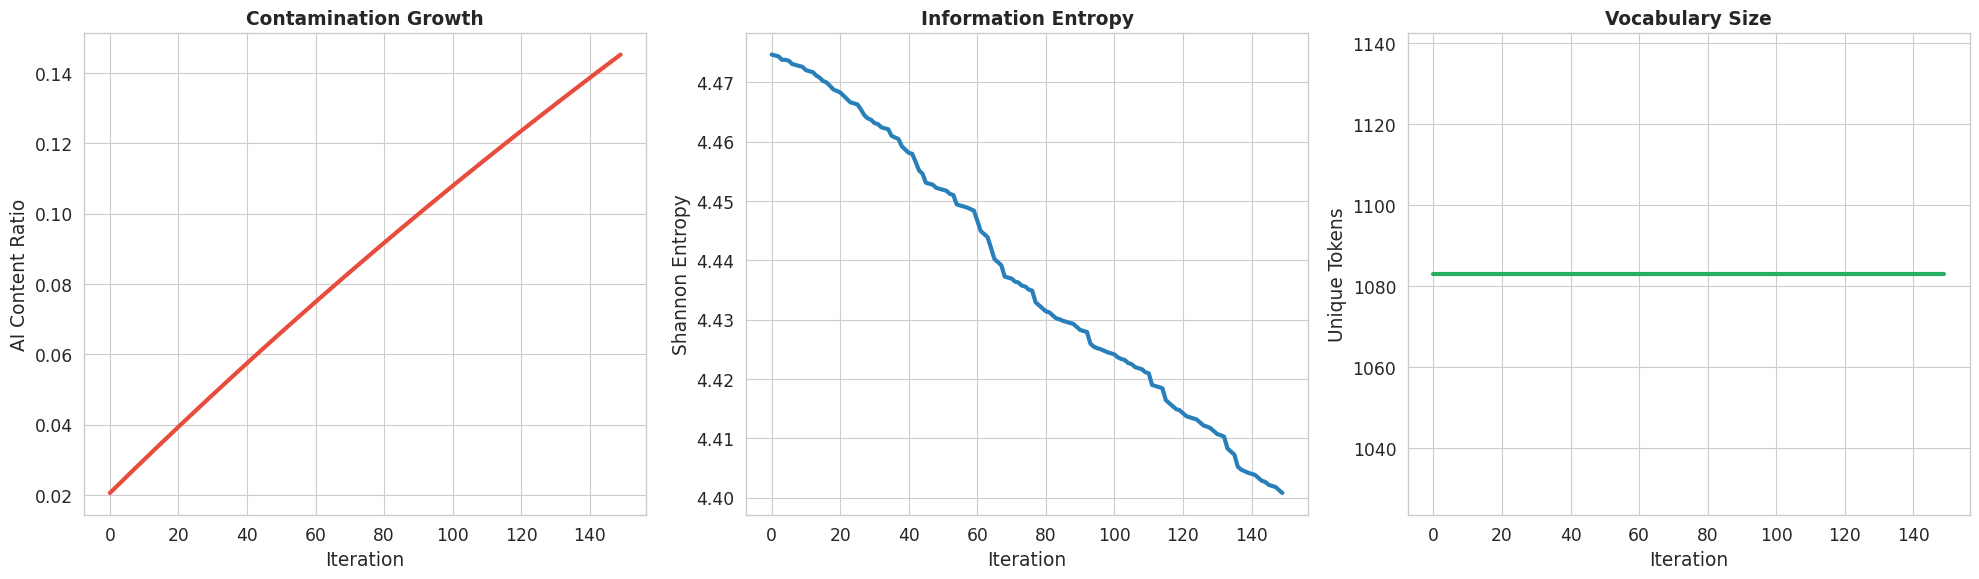

In [ ]:
# %% [markdown]
# ## 5. Publication-Ready Visualizations

# %%
def plot_results(df):
    # Set the style
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.4)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Plot 1: AI Ratio (The S-Curve)
    sns.lineplot(data=df, x='iteration', y='ai_ratio', ax=axes[0], linewidth=3, color='#e74c3c')
    axes[0].set_title('Contamination Growth', fontweight='bold')
    axes[0].set_ylabel('AI Content Ratio')
    axes[0].set_xlabel('Iteration')

    # Plot 2: Entropy (Information Loss)
    sns.lineplot(data=df, x='iteration', y='entropy', ax=axes[1], linewidth=3, color='#2980b9')
    axes[1].set_title('Information Entropy', fontweight='bold')
    axes[1].set_ylabel('Shannon Entropy')
    axes[1].set_xlabel('Iteration')

    # Plot 3: Vocabulary Size (Linguistic Collapse)
    sns.lineplot(data=df, x='iteration', y='vocab_size', ax=axes[2], linewidth=3, color='#27ae60')
    axes[2].set_title('Vocabulary Size', fontweight='bold')
    axes[2].set_ylabel('Unique Tokens')
    axes[2].set_xlabel('Iteration')

    plt.tight_layout()
    plt.savefig(f"{config.RESULTS_DIR}/supplementary_analysis.png", dpi=300)
    print("📈 High-resolution graphs saved.")
    plt.show()

plot_results(df)
df.to_csv(f"{config.RESULTS_DIR}/supplementary_data.csv", index=False)

download results

In [ ]:

# %% [markdown]
import shutil
from google.colab import files
shutil.make_archive('supplementary_results', 'zip', config.RESULTS_DIR)
files.download('supplementary_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>